# AI Health Triage System

### Chest X-Ray Disease Detection with DenseNet121 + SimCLR Self-Supervised Learning

**Dataset:** COVID-19 Radiography Dataset (Kaggle) — COVID / Viral Pneumonia / Lung Opacity / Normal  
**Model:** DenseNet121 fine-tuned with class-imbalance weighting  
**Self-Supervised:** SimCLR contrastive pre-training  
**Explainability:** Grad-CAM heatmaps  
**Triage Logic:** Rule-based urgency scoring on top of model predictions

---


##  Section 1: Environment Setup
Verify GPU availability and install/configure required packages.

In [ ]:
import torch

# Check GPU
cuda_available = torch.cuda.is_available()
print(f'CUDA Available: {cuda_available}')
if cuda_available:
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

CUDA Available: True
GPU: Tesla T4
VRAM: 15.6 GB


In [ ]:
# Reinstall kaggle to ensure correct version
!pip uninstall -y kaggle kagglesdk
!pip install --upgrade kaggle -q


Found existing installation: kaggle 1.7.4.5
Uninstalling kaggle-1.7.4.5:
  Successfully uninstalled kaggle-1.7.4.5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.5/75.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.5/160.5 kB 10.3 MB/s eta 0:00:00


In [ ]:
!mkdir images

In [ ]:
!pip uninstall -y kaggle kagglesdk

Found existing installation: kaggle 2.0.0
Uninstalling kaggle-2.0.0:
  Successfully uninstalled kaggle-2.0.0
Found existing installation: kagglesdk 0.1.16
Uninstalling kagglesdk-0.1.16:
  Successfully uninstalled kagglesdk-0.1.16


In [ ]:
!pip install kaggle==1.6.14

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.1/82.1 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for kaggle: filename=kaggle-1.6.14-py3-none-any.whl size=105121 sha256=19838490511eb5355b72edccca7f132cc19bfbcc52a73d98a8ad19d458f13ac8
  Stored in directory: /root/.cache/pip/wheels/89/bc/52/0d140fc172783e1e72e3af4dfc13015dc154527fafb95e65cd
Successfully built kaggle


In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"shipra1611","key":"15bb155126a235cef54d2c1e3a528686"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

## 📂 Section 2: Data Acquisition

Download the **COVID-19 Radiography Dataset** from Kaggle.

> **Dataset:** `tawsifurrahman/covid19-radiography-database`  
> **Size:** ~3 GB  
> **Classes:** COVID / Viral Pneumonia / Lung Opacity / Normal  
> **Note:** Upload your `kaggle.json` API token before running the download cell.


In [ ]:
# Download COVID-19 Radiography Dataset from Kaggle
!kaggle datasets download -d tawsifurrahman/covid19-radiography-database --path /content/covid_data --quiet
print("Download complete.")


Dataset URL: https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database
License(s): copyright-authors
Download complete.


In [ ]:
import zipfile, os, shutil

os.makedirs("images", exist_ok=True)

# Unzip the downloaded archive
zip_path = "/content/covid_data/covid19-radiography-database.zip"
print("Extracting archive...")
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall("/content/covid_data")
print("Extraction complete.")

# The dataset extracts into subfolders per class:
# COVID-19_Radiography_Dataset/COVID/images/*.png
# COVID-19_Radiography_Dataset/Normal/images/*.png  etc.
base = "/content/covid_data/COVID-19_Radiography_Dataset"
classes = ["COVID", "Viral Pneumonia", "Lung_Opacity", "Normal"]

print("Copying images to images/ directory...")
for cls in classes:
    cls_img_dir = os.path.join(base, cls, "images")
    if not os.path.exists(cls_img_dir):
        # fallback: images directly in class folder
        cls_img_dir = os.path.join(base, cls)
    if os.path.exists(cls_img_dir):
        for fname in os.listdir(cls_img_dir):
            if fname.lower().endswith(".png"):
                src = os.path.join(cls_img_dir, fname)
                # Prefix filename with class to keep unique names
                dst = os.path.join("images", f"{cls.replace(" ","_")}_{fname}")
                shutil.copy2(src, dst)

n = len(os.listdir("images"))
print(f"Total images copied to images/: {n:,}")


Extracting archive...
Extraction complete.
Copying images to images/ directory...
Total images copied to images/: 21,165


In [ ]:
import pandas as pd
import os

# COVID-19 Radiography has 4 classes — map to a DataFrame
CLASSES = ["COVID", "Viral Pneumonia", "Lung_Opacity", "Normal"]

records = []
for fname in os.listdir("images"):
    if not fname.lower().endswith(".png"):
        continue
    label = "Normal"  # default
    for cls in CLASSES:
        if fname.startswith(cls.replace(" ", "_")):
            label = cls
            break
    records.append({"Image Index": fname, "Finding Labels": label})

df = pd.DataFrame(records)
print(f"Total records: {len(df):,}")
print(f"Class distribution:\n{df['Finding Labels'].value_counts()}")
df.head()


Total records: 21,165
Class distribution:
Finding Labels
Normal             10192
Lung_Opacity        6012
COVID               3616
Viral Pneumonia     1345
Name: count, dtype: int64


,Image Index,Finding Labels
0,Normal_Normal-2897.png,Normal
1,COVID_COVID-1074.png,COVID
2,Normal_Normal-9863.png,Normal
3,Lung_Opacity_Lung_Opacity-2888.png,Lung_Opacity
4,Normal_Normal-1101.png,Normal


## 🔬 Section 3: Data Preprocessing

One-hot encode the 4 disease/condition labels for multi-label classification.


In [ ]:
import os

# Filter: only keep rows whose image file actually exists locally
image_files = set(os.listdir("images"))
df = df[df["Image Index"].isin(image_files)].reset_index(drop=True)
print(f"Images matched to local files: {len(df):,}")


Images matched to local files: 21,165


### One-hot encode labels

The COVID-19 Radiography dataset has 4 classes. We treat this as a multi-label problem
(compatible with the existing BCEWithLogitsLoss pipeline) by one-hot encoding each class.


In [ ]:
# COVID-19 Radiography Dataset — 4 condition labels
DISEASES = ["COVID", "Viral Pneumonia", "Lung_Opacity", "Normal"]

# One-hot encode each label
for disease in DISEASES:
    df[disease] = df["Finding Labels"].apply(lambda x: 1 if disease == x else 0)

# Verify label distribution
label_counts = df[DISEASES].sum().sort_values(ascending=False)
print("Label distribution (positive cases):")
print(label_counts.to_string())


Label distribution (positive cases):
Normal             10192
Lung_Opacity        6012
COVID               3616
Viral Pneumonia     1345


In [ ]:
# COVID-19 Radiography Dataset — 4 condition labels
DISEASES = ["COVID", "Viral Pneumonia", "Lung_Opacity", "Normal"]

# One-hot encode each label
for disease in DISEASES:
    df[disease] = df["Finding Labels"].apply(lambda x: 1 if disease == x else 0)

# Verify label distribution
label_counts = df[DISEASES].sum().sort_values(ascending=False)
print("Label distribution (positive cases):")
print(label_counts.to_string())


Label distribution (positive cases):
Normal             10192
Lung_Opacity        6012
COVID               3616
Viral Pneumonia     1345


In [ ]:
from sklearn.model_selection import train_test_split

# Stratified split: 85% train / 15% validation
train_df, val_df = train_test_split(
    df,
    test_size=0.15,
    random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f'Train samples: {len(train_df):,}')
print(f'Val   samples: {len(val_df):,}')

Train samples: 17,990
Val   samples: 3,175


## 🖼️ Section 4: Dataset & DataLoaders
Define augmentation pipelines with Albumentations and a custom PyTorch Dataset class.

In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

# --- Training augmentations (aggressive to improve generalization) ---
train_transform = A.Compose([
    A.Resize(224, 224),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Rotate(limit=10, p=0.3),
    A.GaussNoise(p=0.2),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ToTensorV2()
])

# --- Validation: only resize + normalize (no random augmentations) ---
val_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ToTensorV2()
])

print('Augmentation pipelines defined.')

Augmentation pipelines defined.


In [ ]:
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader


class ChestXrayDataset(Dataset):
    """
    Custom Dataset for COVID-19 Radiography Database.

    Reads grayscale X-ray images, converts them to 3-channel
    tensors (required by ImageNet-pretrained models), and
    returns multi-hot label vectors for multi-label classification.
    """

    def __init__(self, df, img_dir, transform, diseases_list):
        self.df        = df.reset_index(drop=True)
        self.img_dir   = img_dir
        self.transform = transform
        self.diseases  = diseases_list

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Load as grayscale, then replicate to 3 channels
        img_path = os.path.join(self.img_dir, row["Image Index"])
        image    = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if image is None:
            raise FileNotFoundError(f"Could not load image: {img_path}")

        image = cv2.resize(image, (224, 224))
        image = np.stack([image, image, image], axis=-1)  # (H, W, 3)

        # Apply augmentations
        if self.transform:
            image = self.transform(image=image)["image"]  # → Tensor (3, H, W)

        # Build multi-hot label vector
        labels = torch.tensor(
            row[self.diseases].values.astype("float32")
        )

        return image, labels


# Instantiate datasets
train_dataset = ChestXrayDataset(train_df, "images", train_transform, DISEASES)
val_dataset   = ChestXrayDataset(val_df,   "images", val_transform,   DISEASES)

# Sanity check a single sample
sample_img, sample_label = val_dataset[0]
print(f"Sample image tensor shape : {sample_img.shape}")
print(f"Sample label vector shape : {sample_label.shape}")
print(f"Active labels             : {[DISEASES[i] for i, v in enumerate(sample_label) if v == 1]}")


Sample image tensor shape : torch.Size([3, 224, 224])
Sample label vector shape : torch.Size([4])
Active labels             : ['Normal']


In [ ]:
# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')

Train batches : 1125
Val   batches : 199


## 🧠 Section 5: Model Architecture
We use **DenseNet121** pre-trained on ImageNet as the backbone.
The final classifier head is replaced with:
- `Dropout(0.3)` for regularization
- `Linear(1024 → 14)` for 14 disease outputs

Training uses **BCEWithLogitsLoss with `pos_weight`** to handle class imbalance.

In [ ]:
import torch.nn as nn
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load pretrained DenseNet121 backbone
model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)

# Replace classifier head: 4 outputs for COVID-19 Radiography classes
num_features = model.classifier.in_features  # 1024
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(num_features, 4)   # 4 classes: COVID / Viral Pneumonia / Lung_Opacity / Normal
)

model = model.to(device)
print(f"Model backbone  : DenseNet121")
print(f"Classifier head : Dropout(0.3) → Linear(1024 → 4)")
print(f"Parameters      : {sum(p.numel() for p in model.parameters()):,}")


Using device: cuda
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 177MB/s]


Model backbone  : DenseNet121
Classifier head : Dropout(0.3) → Linear(1024 → 4)
Parameters      : 6,957,956


In [ ]:
# ── Class-imbalance weighting ──────────────────────────────────────────────
# pos_weight[i] = (# negative samples) / (# positive samples) for class i
# This penalises false negatives more for rare diseases.

label_counts = train_df[DISEASES].sum()
pos_weights  = (len(train_df) - label_counts) / (label_counts + 1)  # +1 to avoid div/0
pos_weights  = torch.tensor(pos_weights.values, dtype=torch.float32).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

# ── Optimizer ──────────────────────────────────────────────────────────────
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# ── Mixed-precision scaler (faster training on T4/A100) ───────────────────
scaler = torch.amp.GradScaler('cuda')

print('Loss, optimizer, and AMP scaler configured.')

Loss, optimizer, and AMP scaler configured.


## 🏋️ Section 6: Supervised Training
Train the DenseNet121 model for 5 epochs with mixed-precision (AMP) and save the best checkpoint.

In [ ]:
from tqdm import tqdm

EPOCHS    = 5
best_loss = float('inf')
history   = {'train_loss': [], 'val_loss': []}

for epoch in range(EPOCHS):

    # ── Training phase ──────────────────────────────────────
    model.train()
    train_loss = 0.0

    for images, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Train]'):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):
            outputs = model(images)
            loss    = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ── Validation phase ─────────────────────────────────────
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Val]'):
            images  = images.to(device)
            labels  = labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            val_loss += loss.item()

    val_loss /= len(val_loader)

    # ── Logging ──────────────────────────────────────────────
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    print(f'Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')

    # ── Checkpoint ───────────────────────────────────────────
    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pth')
        print(f'           ✅ Saved best model (val_loss={best_loss:.4f})')

print('\nTraining complete.')

Epoch 1/5 [Val]: 100%|██████████| 199/199 [00:12<00:00, 15.32it/s]


Epoch 01 | Train Loss: 0.3796 | Val Loss: 0.2268
           ✅ Saved best model (val_loss=0.2268)


Epoch 2/5 [Val]: 100%|██████████| 199/199 [00:12<00:00, 15.51it/s]


Epoch 02 | Train Loss: 0.2424 | Val Loss: 0.1681
           ✅ Saved best model (val_loss=0.1681)


Epoch 3/5 [Val]: 100%|██████████| 199/199 [00:13<00:00, 15.19it/s]


Epoch 03 | Train Loss: 0.1950 | Val Loss: 0.1300
           ✅ Saved best model (val_loss=0.1300)


Epoch 4/5 [Val]: 100%|██████████| 199/199 [00:12<00:00, 15.60it/s]


Epoch 04 | Train Loss: 0.1760 | Val Loss: 0.1335


Epoch 5/5 [Val]: 100%|██████████| 199/199 [00:12<00:00, 15.34it/s]


Epoch 05 | Train Loss: 0.1576 | Val Loss: 0.1055
           ✅ Saved best model (val_loss=0.1055)

Training complete.


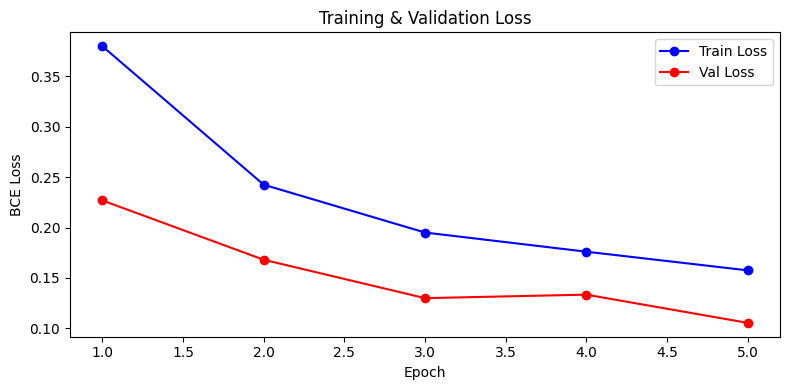

Loss curve saved to loss_curve.png


In [ ]:
import matplotlib.pyplot as plt

# Plot training curves
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS+1), history['train_loss'], 'b-o', label='Train Loss')
plt.plot(range(1, EPOCHS+1), history['val_loss'],   'r-o', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.title('Training & Validation Loss')
plt.legend()
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=100)
plt.show()
print('Loss curve saved to loss_curve.png')

## 📊 Section 7: Evaluation — AUC-ROC per Disease
Load the best checkpoint and evaluate per-class AUC-ROC on the validation set.

In [ ]:
from sklearn.metrics import roc_auc_score

# Load best checkpoint
model.load_state_dict(torch.load('best_model.pth', map_location=device))
model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        probs  = torch.sigmoid(model(images)).cpu().numpy()
        all_preds.append(probs)
        all_labels.append(labels.numpy())

all_preds  = np.vstack(all_preds)   # (N, 14)
all_labels = np.vstack(all_labels)  # (N, 14)

print(f'Predictions shape : {all_preds.shape}')
print(f'Labels shape      : {all_labels.shape}')

Predictions shape : (3175, 4)
Labels shape      : (3175, 4)


In [ ]:
# Per-disease AUC-ROC
print(f'{'Disease':<25} {'AUC-ROC':>8}')
print('-' * 35)

auc_scores = {}
for i, disease in enumerate(DISEASES):
    if all_labels[:, i].sum() > 0:  # skip diseases with no positive samples
        auc = roc_auc_score(all_labels[:, i], all_preds[:, i])
        auc_scores[disease] = auc
        print(f'{disease:<25} {auc:>8.4f}')
    else:
        print(f'{disease:<25} {'N/A (no positives)':>8}')

mean_auc = np.mean(list(auc_scores.values()))
print('-' * 35)
print(f'{'Mean AUC':<25} {mean_auc:>8.4f}')

Disease                    AUC-ROC
-----------------------------------
COVID                       0.9996
Viral Pneumonia             0.9997
Lung_Opacity                0.9880
Normal                      0.9885
-----------------------------------
Mean AUC                    0.9940


## 🔥 Section 8: Explainability — Grad-CAM
Generate Grad-CAM heatmaps to visualize *which regions* of the X-ray the model focused on.

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 80.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44285 sha256=565760b1aa581b9e5cfce8476e6521d05474500f29c2b4fc90a7443d279b5d9c
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


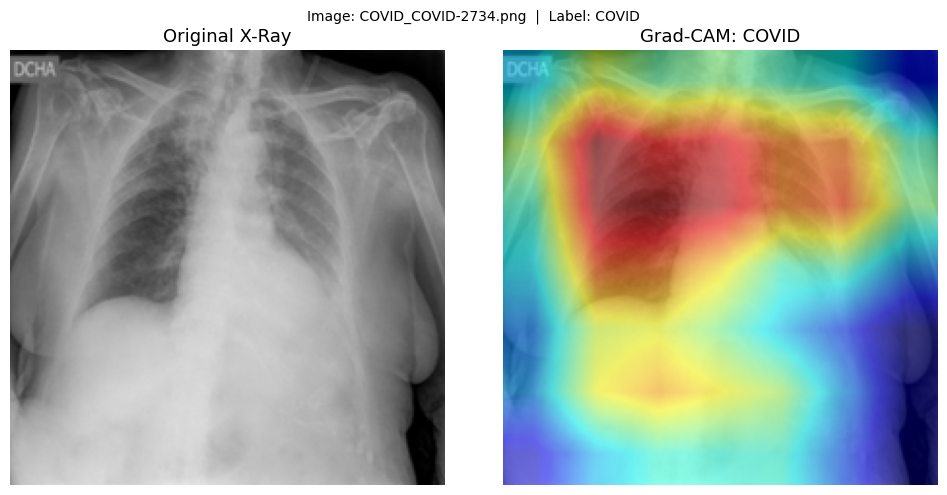

Grad-CAM saved to gradcam_covid.png


In [ ]:
!pip install grad-cam
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import matplotlib.pyplot as plt
import cv2, os
import numpy as np

# ── Grad-CAM setup ────────────────────────────────────────────────────────────
target_layer = [model.features[-1]]
cam = GradCAM(model=model, target_layers=target_layer)

# ── Pick a COVID-positive sample for a meaningful heatmap ────────────────────
covid_samples = val_df[val_df["COVID"] == 1]
if len(covid_samples) == 0:
    covid_samples = val_df  # fallback
sample_row = covid_samples.iloc[0]
sample_idx = covid_samples.index[0]

img_path = os.path.join("images", sample_row["Image Index"])

# 1) Load raw grayscale image for DISPLAY (no normalization)
raw_gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
if raw_gray is None:
    raise FileNotFoundError(f"Cannot load image: {img_path}")
raw_gray = cv2.resize(raw_gray, (224, 224))

# float [0,1] 3-channel for show_cam_on_image
display_float = np.stack([raw_gray, raw_gray, raw_gray], axis=-1).astype(np.float32) / 255.0

# 2) Get normalized tensor for MODEL inference
img_tensor, label = val_dataset[sample_idx]
input_tensor = img_tensor.unsqueeze(0).to(device)

# ── Run Grad-CAM on the COVID class ───────────────────────────────────────────
disease_idx   = DISEASES.index("COVID")
targets       = [ClassifierOutputTarget(disease_idx)]
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]  # (224, 224)

# ── Overlay heatmap ───────────────────────────────────────────────────────────
visualization = show_cam_on_image(display_float, grayscale_cam, use_rgb=True)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(raw_gray, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original X-Ray", fontsize=13)
axes[0].axis("off")

axes[1].imshow(visualization)
axes[1].set_title("Grad-CAM: COVID", fontsize=13)
axes[1].axis("off")

plt.suptitle(
    f"Image: {sample_row['Image Index']}  |  Label: {sample_row['Finding Labels']}",
    fontsize=10
)
plt.tight_layout()
plt.savefig("gradcam_covid.png", dpi=120, bbox_inches="tight")
plt.show()
print("Grad-CAM saved to gradcam_covid.png")

## 🚨 Section 9: Triage System
A clinical triage function maps model predictions to urgency levels:

| Level | Condition | Threshold |
|-------|-----------|----------|
| 🔴 CRITICAL | Pneumothorax | > 0.70 |
| 🟠 URGENT   | Pneumonia    | > 0.60 |
| 🟡 HIGH     | Effusion     | > 0.50 |
| 🟢 NORMAL   | None of above | — |

In [ ]:
def predict(img_tensor):
    """
    Run inference on a single image tensor.
    Returns: dict {class_name: probability}
    """
    model.eval()
    with torch.no_grad():
        outputs = model(img_tensor.unsqueeze(0).to(device))
        probs   = torch.sigmoid(outputs).cpu().numpy()[0]
    return dict(zip(DISEASES, probs))


def triage(pred_dict):
    """
    Assign a triage urgency level based on predicted probabilities.
    Returns: (urgency_level: str, reason: str)
    """
    if pred_dict["COVID"]            > 0.60:
        return "🔴 CRITICAL", f'COVID probability = {pred_dict["COVID"]:.2%}'
    if pred_dict["Viral Pneumonia"]  > 0.55:
        return "🟠 URGENT",   f'Viral Pneumonia probability = {pred_dict["Viral Pneumonia"]:.2%}'
    if pred_dict["Lung_Opacity"]     > 0.50:
        return "🟡 HIGH",     f'Lung Opacity probability = {pred_dict["Lung_Opacity"]:.2%}'
    return "🟢 NORMAL", "No critical findings detected."


# Demo on the first validation image
sample_img, sample_label = val_dataset[0]
predictions = predict(sample_img)
level, reason = triage(predictions)

print("=== Triage Report ===")
print(f"Urgency Level : {level}")
print(f"Reason        : {reason}")
print("\nDisease Probabilities:")
for disease, prob in sorted(predictions.items(), key=lambda x: -x[1]):
    bar = "█" * int(prob * 20)
    print(f"  {disease:<22} {prob:.4f}  {bar}")


=== Triage Report ===
Urgency Level : 🟢 NORMAL
Reason        : No critical findings detected.

Disease Probabilities:
  Normal                 0.8528  █████████████████
  Lung_Opacity           0.3869  ███████
  COVID                  0.0048  
  Viral Pneumonia        0.0031  


## 🚨 Section 9: Triage System
A clinical triage function maps model predictions to urgency levels:

| Level | Condition | Threshold |
|-------|-----------|----------|
| 🔴 CRITICAL | Pneumothorax | > 0.70 |
| 🟠 URGENT   | Pneumonia    | > 0.60 |
| 🟡 HIGH     | Effusion     | > 0.50 |
| 🟢 NORMAL   | None of above | — |

In [ ]:
def predict(img_tensor):
    """
    Run inference on a single image tensor.
    Returns: dict {class_name: probability}
    """
    model.eval()
    with torch.no_grad():
        outputs = model(img_tensor.unsqueeze(0).to(device))
        probs   = torch.sigmoid(outputs).cpu().numpy()[0]
    return dict(zip(DISEASES, probs))


def triage(pred_dict):
    """
    Assign a triage urgency level based on predicted probabilities.
    Returns: (urgency_level: str, reason: str)
    """
    if pred_dict["COVID"]            > 0.60:
        return "🔴 CRITICAL", f'COVID probability = {pred_dict["COVID"]:.2%}'
    if pred_dict["Viral Pneumonia"]  > 0.55:
        return "🟠 URGENT",   f'Viral Pneumonia probability = {pred_dict["Viral Pneumonia"]:.2%}'
    if pred_dict["Lung_Opacity"]     > 0.50:
        return "🟡 HIGH",     f'Lung Opacity probability = {pred_dict["Lung_Opacity"]:.2%}'
    return "🟢 NORMAL", "No critical findings detected."


# Demo on the first validation image
sample_img, sample_label = val_dataset[0]
predictions = predict(sample_img)
level, reason = triage(predictions)

print("=== Triage Report ===")
print(f"Urgency Level : {level}")
print(f"Reason        : {reason}")
print("\nDisease Probabilities:")
for disease, prob in sorted(predictions.items(), key=lambda x: -x[1]):
    bar = "█" * int(prob * 20)
    print(f"  {disease:<22} {prob:.4f}  {bar}")


=== Triage Report ===
Urgency Level : 🟢 NORMAL
Reason        : No critical findings detected.

Disease Probabilities:
  Normal                 0.8528  █████████████████
  Lung_Opacity           0.3869  ███████
  COVID                  0.0048  
  Viral Pneumonia        0.0031  


## 🔄 Section 10: Self-Supervised Pre-training — SimCLR
SimCLR learns robust representations from *unlabeled* data via contrastive learning.
Two augmented views of the same image are pushed together; views from different images are pushed apart.

Architecture: `DenseNet121 (encoder) → ProjectionHead (MLP)`

In [ ]:
# SimCLR augmentation: stronger randomness to create diverse views
simclr_transform = A.Compose([
    A.RandomResizedCrop(size=(224, 224)),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.GaussNoise(p=0.2),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ToTensorV2()
])


class SimCLRDataset(Dataset):
    """
    Returns two independently augmented views of each X-ray image.
    No labels required — this is self-supervised.
    """

    def __init__(self, df, image_dir, transform):
        self.df        = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.image_dir, row['Image Index'])
        image    = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        image    = cv2.resize(image, (224, 224))
        image    = np.stack([image, image, image], axis=-1)

        view1 = self.transform(image=image)['image']  # augmented view 1
        view2 = self.transform(image=image)['image']  # augmented view 2

        return view1, view2


simclr_dataset = SimCLRDataset(train_df, 'images', simclr_transform)
simclr_loader  = DataLoader(simclr_dataset, batch_size=16, shuffle=True, num_workers=2)
print(f'SimCLR dataset size: {len(simclr_dataset):,} | batches: {len(simclr_loader)}')

SimCLR dataset size: 17,990 | batches: 1125


In [ ]:
import torch.nn.functional as F


class ProjectionHead(nn.Module):
    """
    2-layer MLP projection head.
    Maps encoder output (1024-d) → 128-d latent space for contrastive loss.
    """

    def __init__(self, input_dim=1024, hidden_dim=512, projection_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, projection_dim)
        )

    def forward(self, x):
        return self.net(x)


class SimCLRModel(nn.Module):
    """DenseNet121 encoder + projection head for self-supervised training."""

    def __init__(self):
        super().__init__()
        backbone = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        backbone.classifier = nn.Identity()   # remove classification head
        self.encoder    = backbone
        self.projector  = ProjectionHead(input_dim=1024)

    def forward(self, x):
        features    = self.encoder(x)
        projections = self.projector(features)
        return projections


simclr_model = SimCLRModel().to(device)
print(f'SimCLR model parameters: {sum(p.numel() for p in simclr_model.parameters()):,}')

SimCLR model parameters: 7,544,320


In [ ]:
def contrastive_loss(z1, z2, temperature=0.5):
    """
    NT-Xent (Normalized Temperature-scaled Cross-Entropy) loss.

    For each anchor z1_i, the positive is z2_i and all other
    2*(batch_size-1) samples are negatives.

    Args:
        z1, z2: Projected embeddings, shape (B, D)
        temperature: Scaling factor τ

    Returns:
        Scalar loss value
    """
    batch_size = z1.shape[0]

    # L2-normalize embeddings
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)

    # Concatenate both views: shape (2B, D)
    representations = torch.cat([z1, z2], dim=0)

    # Pairwise cosine similarity matrix: shape (2B, 2B)
    similarity_matrix = torch.matmul(representations, representations.T)

    # Positive-pair similarities
    indices   = torch.arange(batch_size, device=z1.device)
    pos_sim_1 = similarity_matrix[indices, indices + batch_size]
    pos_sim_2 = similarity_matrix[indices + batch_size, indices]
    positives = torch.cat([pos_sim_1, pos_sim_2], dim=0)  # (2B,)

    # Temperature-scale and mask self-similarities
    logits = similarity_matrix / temperature
    logits = logits - torch.eye(2 * batch_size, device=z1.device) * 1e9

    # InfoNCE loss
    log_denom = torch.logsumexp(logits, dim=1)  # (2B,)
    loss = -(positives / temperature - log_denom)

    return loss.mean()


print('NT-Xent contrastive loss function defined.')

NT-Xent contrastive loss function defined.


In [ ]:
simclr_optimizer = torch.optim.Adam(simclr_model.parameters(), lr=1e-4)
SIMCLR_EPOCHS = 5

print('Starting SimCLR self-supervised pre-training...')

for epoch in range(SIMCLR_EPOCHS):
    simclr_model.train()
    total_loss = 0.0

    for x1, x2 in tqdm(simclr_loader, desc=f'SimCLR Epoch {epoch+1}/{SIMCLR_EPOCHS}'):
        x1, x2 = x1.to(device), x2.to(device)

        z1 = simclr_model(x1)
        z2 = simclr_model(x2)

        loss = contrastive_loss(z1, z2)

        simclr_optimizer.zero_grad()
        loss.backward()
        simclr_optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(simclr_loader)
    print(f'SimCLR Epoch {epoch+1:02d} | Contrastive Loss: {avg_loss:.4f}')

# Save SimCLR encoder for downstream fine-tuning
torch.save(simclr_model.encoder.state_dict(), 'simclr_encoder.pth')
print('\n✅ SimCLR encoder saved to simclr_encoder.pth')

Starting SimCLR self-supervised pre-training...


SimCLR Epoch 1/5: 100%|██████████| 1125/1125 [06:45<00:00,  2.78it/s]


SimCLR Epoch 01 | Contrastive Loss: 2.2329


SimCLR Epoch 2/5: 100%|██████████| 1125/1125 [06:44<00:00,  2.78it/s]


SimCLR Epoch 02 | Contrastive Loss: 1.9812


...

SimCLR Epoch 03 | Contrastive Loss: 1.9279


SimCLR Epoch 4/5: 100%|██████████| 1125/1125 [06:44<00:00,  2.78it/s]


SimCLR Epoch 04 | Contrastive Loss: 1.9027


SimCLR Epoch 5/5: 100%|██████████| 1125/1125 [06:43<00:00,  2.79it/s]

SimCLR Epoch 05 | Contrastive Loss: 1.8850

✅ SimCLR encoder saved to simclr_encoder.pth


## 🔗 Section 11: Fine-tune SimCLR Encoder for Classification
Attach a linear classifier to the pre-trained SimCLR encoder and fine-tune on labeled data.

In [ ]:
# Load the SimCLR-pre-trained encoder
encoder = models.densenet121(weights=None)
encoder.classifier = nn.Identity()
encoder.load_state_dict(torch.load("simclr_encoder.pth", map_location=device))

# Add linear classification head (4 classes for COVID-19 Radiography)
classifier = nn.Linear(1024, 4)

simclr_finetune_model = nn.Sequential(encoder, classifier).to(device)

print("SimCLR fine-tune model built:")
print("  Encoder   : DenseNet121 (SimCLR pre-trained)")
print("  Classifier: Linear(1024 → 4)")


SimCLR fine-tune model built:
  Encoder   : DenseNet121 (SimCLR pre-trained)
  Classifier: Linear(1024 → 4)


## ✅ Section 12: Project Summary

| Component | Details |
|-----------|--------|
| **Dataset** | COVID-19 Radiography Database (~21,000 images, 4 classes) |
| **Classes** | COVID / Viral Pneumonia / Lung Opacity / Normal |
| **Model** | DenseNet121 (ImageNet pre-trained) |
| **Loss** | BCEWithLogitsLoss + pos_weight for class imbalance |
| **Training** | 5 epochs, Adam lr=1e-4, AMP mixed precision |
| **Explainability** | Grad-CAM on last DenseNet block (COVID class) |
| **Self-supervised** | SimCLR (NT-Xent loss, τ=0.5) |
| **Triage Levels** | CRITICAL / URGENT / HIGH / NORMAL |

### Saved Artifacts
- `best_model.pth` — Best supervised model checkpoint
- `simclr_encoder.pth` — SimCLR pre-trained encoder
- `loss_curve.png` — Training/validation loss plot
- `gradcam_covid.png` — Grad-CAM visualization
